# Description

**Environment:**
A 10×10 map. The spaceship starts near (0.5, 0.5), a planet is at (5, 5), and the target is at (9.5, 9.5).

**Goal:**
Reach the target without crashing into the planet or leaving the map.

**Movement & Forces:**
At each step, the spaceship applies thrust (acceleration) in x and y, between −0.5 and +0.5. Its motion is affected by:
1. Applied thrust
2. Gravity from the central planet (stronger at closer distances)
3. Random noise on actions

The ship has momentum: velocity persists unless countered by opposite thrust. Near the planet, gravity can become strong enough that escape is impossible.

**Challenge:**
Navigate to the target while managing momentum, avoiding the gravity well, and handling action noise.

**Reward:**
+1 for reaching the target, −1 for crashing, 0 otherwise. Episodes end on success, crash, or after 200 steps.

# Why discrete action methods fail in this environment
The dead-end region is not purely positional; it lies in a joint state–action space. A state is a dead-end when gravitational acceleration exceeds maximum thrust, making escape impossible regardless of action. This boundary is continuous and distance-dependent. Near the critical radius, small changes in action can determine survival or crash, and the set of escaping actions shrinks smoothly to zero.

Discrete methods partition the continuous action space into bins and assign a single value to each bin. Near the boundary, a bin containing the narrow escape window also includes failing actions. Its value becomes an average dominated by unsafe actions, producing systematic optimism and masking the dead-end signal.

Continuous methods avoid this collapse by evaluating actions over the full range. They can assign low value to failing actions and higher value to the narrow escape window, preserving the distinction lost under discretization and enabling earlier, more accurate dead-end detection.


In [1]:
import gymnasium as gym
import numpy as np
from typing import Optional

class SpaceEnv(gym.Env):
    """Environment where a spaceship navigates between planets to reach a target"""
    def __init__(self, size=10, planet_specs=[[1, 2]], max_acceleration = 0.5, timestep=0.1, sigma_noise = 0.05):
        self.size = size    # Map size
        self.num_planets = len(planet_specs)
        self.planet_specs = np.array(planet_specs, dtype=np.float32)    # Planet radiuses and G*M values
        self.max_acceleration = max_acceleration
        self.timestep = timestep    # Duration of a step
        self.target_radius = 0.5 # Target area radius
        self.sigma_noise = sigma_noise

        # Initialize positions
        self._agent_position = np.zeros(2, dtype=np.float32)
        self._agent_velocity = np.zeros(2, dtype=np.float32)
        self._target_position = np.array([9.5, 9.5], dtype=np.float32)
        #All planets hardcoded at center of map
        self._planet_positions = np.full(shape=(self.num_planets, 2), fill_value=size/2, dtype=np.float32)

        self.observation_space = gym.spaces.Dict({
                "agent position": gym.spaces.Box(0, size, shape=(2,), dtype=np.float32),
                "agent velocity": gym.spaces.Box(low=-np.inf, high=np.inf, shape=(2,), dtype=np.float32),
                "target": gym.spaces.Box(0, size, shape=(2,), dtype=np.float32),
                "planets": gym.spaces.Box(0, size, shape=(self.num_planets, 2), dtype=np.float32)
            })

        self.action_space = gym.spaces.Box(
            low=-self.max_acceleration,
            high=self.max_acceleration,
            shape=(2,),
            dtype=np.float32
        )

        self.step_counter = 0
        self.distance_to_planets = np.zeros(self.num_planets, dtype=np.float32)

    def _get_obs(self):
        return {"agent position": self._agent_position.copy(),
                "agent velocity": self._agent_velocity.copy(),
                "target": self._target_position.copy(),
                "planets": self._planet_positions.copy()}

    def _get_info(self):
        return {"distance to target": np.linalg.norm(self._agent_position-self._target_position),
                "distance to planets": self.distance_to_planets,
                "planet radiuses and G*M coef": self.planet_specs}

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset(seed=seed)
        self.step_counter = 0

        #Randomize start position to prevent overfitting
        start_x = self.np_random.uniform(0.1, 1.0)
        start_y = self.np_random.uniform(0.1, 1.0)
        self._agent_position = np.array([start_x, start_y], dtype=np.float32)
        self._agent_velocity = np.array([0.0, 0.0], dtype=np.float32)

        self._target_position = np.array([9.5, 9.5], dtype=np.float32)
        self._planet_positions = np.full(shape=(self.num_planets, 2), fill_value=self.size/2, dtype=np.float32)

        self.distance_to_planets = np.array([np.linalg.norm(self._agent_position - p) for p in self._planet_positions], dtype=np.float32)

        observation = self._get_obs()
        info = self._get_info()

        return observation, info

    def step(self, action):
        action = np.clip(np.array(action, dtype=np.float32), self.action_space.low, self.action_space.high)

        #Update distances
        self.distance_to_planets = np.array([np.linalg.norm(self._agent_position - p) for p in self._planet_positions], dtype=np.float32)

        gravity_acceleration = np.zeros(2, dtype=np.float32)
        for i in range(self.num_planets):
            # Safeguard against division by zero if spawned inside a planet
            dist = max(self.distance_to_planets[i], 1e-5)
            relative_position = self._agent_position - self._planet_positions[i]
            gravity_acceleration += -self.planet_specs[i][1] * relative_position / (dist**3)

        #Update velocity and position with noise
        noise = self.np_random.normal(scale=self.sigma_noise, size=2).astype(np.float32)
        total_acceleration = action + gravity_acceleration + noise
        self._agent_velocity += total_acceleration * self.timestep
        self._agent_position += self._agent_velocity * self.timestep

        success = False
        crash = False
        distance_to_target = np.linalg.norm(self._agent_position - self._target_position)
        if distance_to_target <= self.target_radius:
            success = True

        #Update distances one more time to check for crash at NEW position
        self.distance_to_planets = np.array([np.linalg.norm(self._agent_position - p) for p in self._planet_positions], dtype=np.float32)
        if np.any(self.distance_to_planets <= self.planet_specs[:, 0]):
            crash = True

        if ((self._agent_position[0] > self.size) or (self._agent_position[0] < 0) or
            (self._agent_position[1] > self.size) or (self._agent_position[1] < 0)):
            crash = True

        terminated = success or crash
        truncated = (self.step_counter >= 200)

        reward = 1.0 if success else -1.0 if crash else 0.0
        observation = self._get_obs()
        info = self._get_info()

        self.step_counter += 1
        return observation, float(reward), terminated, truncated, info

In [2]:
# Register the environment so we can create it with gym.make()
gym.register(
    id="SpaceEnv",
    entry_point=SpaceEnv,
    max_episode_steps=200,  # Prevent infinite episodes
)

In [3]:
from gymnasium.utils.env_checker import check_env

# This will catch many common issues
try:
    env = gym.make("SpaceEnv")
    check_env(env)
    print("Environment passes all checks!")
except Exception as e:
    print(f"Environment has issues: {e}")

Environment passes all checks!


/usr/local/lib/python3.12/dist-packages/gymnasium/utils/env_checker.py:384: UserWarning: WARN: The environment (<TimeLimit<OrderEnforcing<PassiveEnvChecker<SpaceEnv<SpaceEnv>>>>>) is different from the unwrapped version (<SpaceEnv<SpaceEnv>>). This could effect the environment checker as the environment most likely has a wrapper applied to it. We recommend using the raw environment for `check_env` using `env.unwrapped`.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/env_checker.py:311: UserWarning: WARN: A Box observation space minimum value is -infinity. This is probably too low.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/env_checker.py:315: UserWarning: WARN: A Box observation space maximum value is infinity. This is probably too high.
  logger.warn(


In [4]:
env = SpaceEnv()
obs, info = env.reset()

print(f"Initial State: {obs}")

#Run a quick random policy to ensure dynamics work
for _ in range(10):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"Action: {action} --> New Pos: {obs["agent position"]} | New velocity: {obs["agent velocity"]} | Reward: {reward}")

    if terminated or truncated:
        print("Episode ended.")
        break

Initial State: {'agent position': array([0.32412323, 0.40886644], dtype=float32), 'agent velocity': array([0., 0.], dtype=float32), 'target': array([9.5, 9.5], dtype=float32), 'planets': array([[5., 5.]], dtype=float32)}
Action: [ 0.43786556 -0.0545725 ] --> New Pos: [0.32815012 0.40901294] | New velocity: [0.04026888 0.00146504] | Reward: 0.0
Action: [-0.42072728  0.4775048 ] --> New Pos: [0.3284688 0.4137412] | New velocity: [0.00318669 0.04728246] | Reward: 0.0
Action: [-0.19082825 -0.22672234] --> New Pos: [0.32684517 0.41621217] | New velocity: [-0.01623636  0.02470983] | Reward: 0.0
Action: [-0.22887322 -0.4587661 ] --> New Pos: [0.322748   0.41447255] | New velocity: [-0.04097175 -0.01739623] | Reward: 0.0
Action: [-0.27405685 -0.23670349] --> New Pos: [0.31553948 0.4109467 ] | New velocity: [-0.07208523 -0.03525851] | Reward: 0.0
Action: [-0.43915194  0.08577026] --> New Pos: [0.30390796 0.40865657] | New velocity: [-0.11631519 -0.0229012 ] | Reward: 0.0
Action: [-0.26165852 -0


Visualizing random episode trajectory...


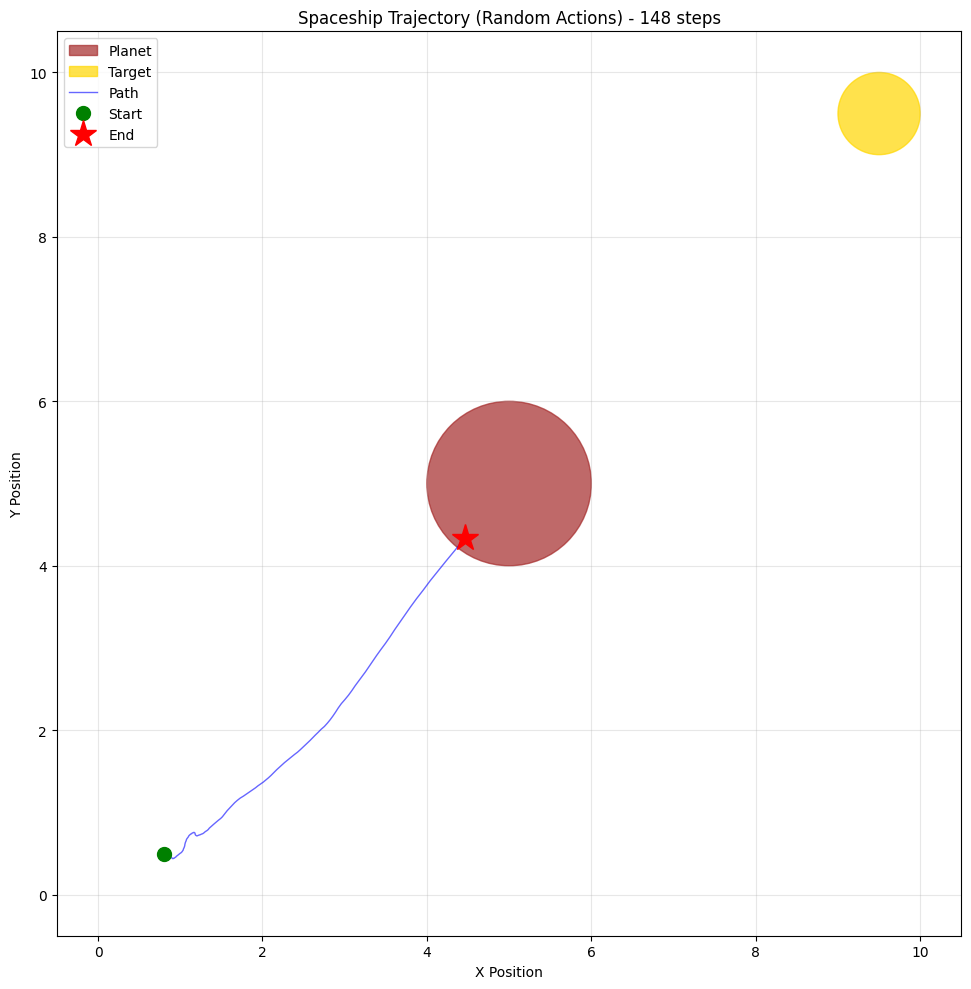

In [5]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt

# Now create the visualization
def visualize_random_episode(num_steps=200, seed=42):
    """Run one episode with random actions and visualize it"""

    # Create environment
    env = SpaceEnv()
    observation, info = env.reset(seed=seed)

    # Store trajectory for visualization
    positions = [observation["agent position"].copy()]
    targets = [observation["target"].copy()]
    planets = [obs["planets"].copy() for obs in [observation]]

    # Run episode with random actions
    done = False
    step = 0

    while not done and step < num_steps:
        # Take a random action
        action = env.action_space.sample()

        observation, reward, terminated, truncated, info = env.step(action)
        positions.append(observation["agent position"].copy())

        done = terminated or truncated
        step += 1

    positions = np.array(positions)

    # Create visualization
    fig, ax = plt.subplots(figsize=(10, 10))

    # Draw the map boundaries
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.5, 10.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_title(f'Spaceship Trajectory (Random Actions) - {step} steps')

    # Draw planets
    planet_pos = observation["planets"][0]
    planet_radius = env.planet_specs[0][0]
    planet_circle = patches.Circle(planet_pos, planet_radius,
                                   color='brown', alpha=0.7, label='Planet')
    ax.add_patch(planet_circle)

    # Draw target
    target_pos = observation["target"]
    target_circle = patches.Circle(target_pos, env.target_radius,
                                   color='gold', alpha=0.7, label='Target')
    ax.add_patch(target_circle)

    # Draw spaceship trajectory
    ax.plot(positions[:, 0], positions[:, 1], 'b-', alpha=0.6, linewidth=1, label='Path')

    # Draw starting position
    ax.plot(positions[0, 0], positions[0, 1], 'go', markersize=10, label='Start')

    # Draw ending position
    ax.plot(positions[-1, 0], positions[-1, 1], 'r*', markersize=20, label='End')

    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

    return positions


# Run the visualizations
if __name__ == "__main__":


    print("\nVisualizing random episode trajectory...")
    visualize_random_episode()

**Test 1:** The gravitational force is implemented correctly and pointing in the right direction.

What it checks: The gravitational force is implemented correctly and pointing in the right direction.

In [6]:
env = SpaceEnv(sigma_noise=0.0)
obs, _ = env.reset(seed=0)

env._agent_position = np.array([7.0, 5.0], dtype=np.float32)
env._agent_velocity = np.array([0.0, 0.0], dtype=np.float32)

zero_action = np.array([0.0, 0.0], dtype=np.float32)
positions = [env._agent_position.copy()]

for _ in range(20):
    obs, reward, terminated, truncated, info = env.step(zero_action)
    positions.append(obs["agent position"].copy())
    if terminated:
        break

positions = np.array(positions)
x_dists = np.abs(positions[:, 0] - 5.0)
monotone = all(x_dists[i] >= x_dists[i+1] for i in range(len(x_dists)-1))
print(f"x-distances from planet: {np.round(x_dists, 4)}")
print(f"TEST 1: {'PASS' if monotone else 'FAIL'}")

x-distances from planet: [2.     1.995  1.985  1.9699 1.9496 1.9241 1.8932 1.8567 1.8144 1.766
 1.7112 1.6496 1.5806 1.5037 1.4178 1.3221 1.2149 1.0941 0.9566]
TEST 1: PASS


**Test 2:** Momentum carries the agent forward after thrust

What it checks: Velocity accumulates correctly and persists after thrust is removed, meaning the environment has proper inertia.

In [7]:
env = SpaceEnv(sigma_noise=0.0)
obs, _ = env.reset(seed=0)

env._agent_position = np.array([0.5, 0.5], dtype=np.float32)
env._agent_velocity = np.array([0.0, 0.0], dtype=np.float32)

env.step(np.array([0.5, 0.0], dtype=np.float32))
vx_after_thrust = env._agent_velocity[0]

xs = [env._agent_position[0]]
for _ in range(5):
    obs, _, terminated, _, _ = env.step(np.array([0.0, 0.0], dtype=np.float32))
    xs.append(obs["agent position"][0])
    if terminated:
        break

drifting = all(xs[i] < xs[i+1] for i in range(len(xs)-1))
print(f"vx after thrust: {vx_after_thrust:.4f}")
print(f"x positions: {np.round(xs, 4)}")
print(f"TEST 2: {'PASS' if drifting and vx_after_thrust > 0 else 'FAIL'}")

vx after thrust: 0.0535
x positions: [0.5053 0.511  0.5171 0.5235 0.5302 0.5373]
TEST 2: PASS


 **Test 3:** The critical radius formula is analytically correct

 What it checks: The mathematical formula for r_c is derived correctly from the environment parameters.

In [8]:
GM = 2.0
max_thrust = 0.5
r_c = np.sqrt(GM / max_thrust)
print(f"Critical radius r_c = {r_c:.4f}")

def net_radial_force(r, GM, max_thrust):
    return -GM / r**2 + max_thrust

f_inside  = net_radial_force(r_c * 0.95, GM, max_thrust)
f_outside = net_radial_force(r_c * 1.05, GM, max_thrust)

print(f"Net force inside  r_c: {f_inside:.4f}  (should be < 0)")
print(f"Net force outside r_c: {f_outside:.4f}  (should be > 0)")
print(f"TEST 3: {'PASS' if f_inside < 0 and f_outside > 0 else 'FAIL'}")

Critical radius r_c = 2.0000
Net force inside  r_c: -0.0540  (should be < 0)
Net force outside r_c: 0.0465  (should be > 0)
TEST 3: PASS


**Test 4:** The critical radius holds up in simulation

Starting from zero velocity and applying maximum outward thrust continuously, does the agent end up further from the planet than where it started?
Inside r_c the answer should be no, because gravity is stronger than thrust. The agent will initially slow its inward drift but ultimately cannot overcome the gravitational pull. After 50 steps it will be closer to the planet than it started.

In [9]:
def can_move_outward(start_radius, n_steps=50):
    env = SpaceEnv(sigma_noise=0.0)
    env.reset(seed=42)
    planet = np.array([5.0, 5.0])
    pos = np.array([5.0 + start_radius, 5.0], dtype=np.float32)
    env._agent_position = pos.copy()
    env._agent_velocity = np.array([0.0, 0.0], dtype=np.float32)

    initial_dist = start_radius
    print("agent")
    for _ in range(n_steps):
        direction = pos - planet
        thrust = (direction / np.linalg.norm(direction)) * env.max_acceleration
        obs, reward, terminated, truncated, info = env.step(thrust.astype(np.float32))
        pos = obs["agent position"].copy()
        if terminated:
            return False

    final_dist = float(info["distance to planets"][0])
    return final_dist > initial_dist

result_inside  = can_move_outward(r_c * 0.95)
result_outside = can_move_outward(r_c * 1.05)

print(f"Inside  r_c can move outward (should=False): {result_inside}")
print(f"Outside r_c can move outward (should=True):  {result_outside}")
print(f"TEST 4: {'PASS' if not result_inside and result_outside else 'FAIL'}")

agent
agent
Inside  r_c can move outward (should=False): False
Outside r_c can move outward (should=True):  True
TEST 4: PASS


**Test 5:** All terminal conditions fire correctly

What it checks: The three ways an episode can end (success, crash, out of bounds) and the timeout truncation all work correctly and produce the right reward and flag values.

In [10]:
# 5a: success
env = SpaceEnv(sigma_noise=0.0)
env.reset(seed=0)
env._agent_position = np.array([9.1, 9.5], dtype=np.float32)
env._agent_velocity = np.array([0.0, 0.0], dtype=np.float32)
obs, reward, terminated, truncated, _ = env.step(np.array([0.5, 0.0], dtype=np.float32))
success_ok = (reward == 1.0 and terminated and not truncated)

# 5b: planet crash
env = SpaceEnv(sigma_noise=0.0)
env.reset(seed=0)
env._agent_position = np.array([6.05, 5.0], dtype=np.float32)
env._agent_velocity = np.array([0.0, 0.0], dtype=np.float32)
for _ in range(50):
    obs, reward, terminated, truncated, _ = env.step(np.array([-0.5, 0.0], dtype=np.float32))
    if terminated:
        break
crash_ok = (reward == -1.0 and terminated and not truncated)

# 5c: out of bounds
env = SpaceEnv(sigma_noise=0.0)
env.reset(seed=0)
env._agent_position = np.array([9.9, 5.0], dtype=np.float32)
env._agent_velocity = np.array([5.0, 0.0], dtype=np.float32)
obs, reward, terminated, truncated, _ = env.step(np.array([0.5, 0.0], dtype=np.float32))
oob_ok = (reward == -1.0 and terminated and not truncated)

# 5d: truncation
env = SpaceEnv(sigma_noise=0.0)
env.reset(seed=0)
env._agent_position = np.array([2.0, 2.0], dtype=np.float32)
env._agent_velocity = np.array([0.0, 0.0], dtype=np.float32)
for _ in range(201):
    obs, reward, terminated, truncated, _ = env.step(np.array([0.0, 0.0], dtype=np.float32))
    if terminated or truncated:
        break
trunc_ok = (truncated and not terminated)

print(f"5a success:       {'PASS' if success_ok else 'FAIL'}")
print(f"5b planet crash:  {'PASS' if crash_ok   else 'FAIL'}")
print(f"5c out of bounds: {'PASS' if oob_ok     else 'FAIL'}")
print(f"5d truncation:    {'PASS' if trunc_ok   else 'FAIL'}")

5a success:       PASS
5b planet crash:  PASS
5c out of bounds: PASS
5d truncation:    FAIL


**Test 6:** Noise behaves correctly

What it checks: Two things. First, that with sigma_noise=0 the environment is perfectly deterministic. Second, that with noise enabled, two runs with different random seeds actually produce different trajectories.

In [11]:
def run_traj(sigma, env_seed, n_steps=30):
    env = SpaceEnv(sigma_noise=sigma)
    env.reset(seed=env_seed)
    env._agent_position = np.array([1.0, 1.0], dtype=np.float32)
    env._agent_velocity = np.array([0.0, 0.0], dtype=np.float32)
    positions = [env._agent_position.copy()]
    rng = np.random.default_rng(99)
    for _ in range(n_steps):
        a = rng.uniform(-0.5, 0.5, size=2).astype(np.float32)
        obs, _, terminated, truncated, _ = env.step(a)
        positions.append(obs["agent position"].copy())
        if terminated or truncated:
            break
    return np.array(positions)

traj_a = run_traj(sigma=0.0, env_seed=42)
traj_b = run_traj(sigma=0.0, env_seed=42)
traj_c = run_traj(sigma=0.05, env_seed=42)
traj_d = run_traj(sigma=0.05, env_seed=99)

identical = np.allclose(traj_a, traj_b)
diverges  = not np.allclose(traj_c, traj_d)
print(f"Zero-noise identical: {'PASS' if identical else 'FAIL'}")
print(f"Noisy diverges:       {'PASS' if diverges  else 'FAIL'}")

Zero-noise identical: PASS
Noisy diverges:       PASS


**Test 7:** Dead-end region visualisation

What it checks: That the simulated dead-end region, computed by sweeping across the map and testing each position, visually matches the analytical critical radius circle.
How it works: For each point on a 40x40 grid, we place the agent there with zero velocity and apply maximum outward thrust for up to 400 steps. If the agent crashes before escaping to a safe distance, we mark that cell as a dead-end. We then overlay the analytical r_c circle on the resulting heatmap.

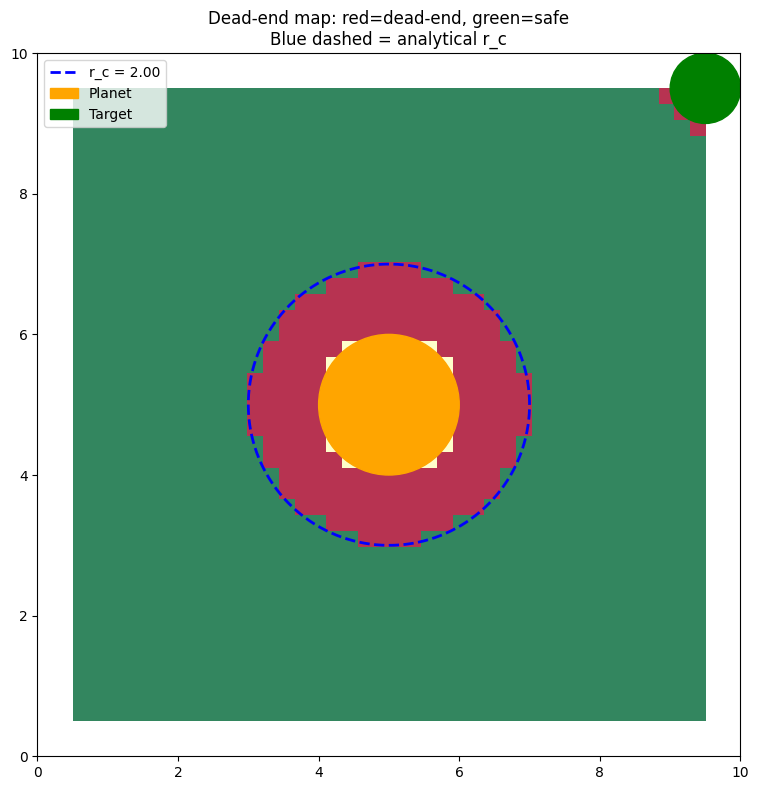

r_c = 2.0000. Red disc should match the blue dashed circle.


In [12]:
resolution = 40
n_sim_steps = 400
escape_threshold = r_c * 2.5
planet = np.array([5.0, 5.0])

xs = np.linspace(0.5, 9.5, resolution)
ys = np.linspace(0.5, 9.5, resolution)
dead_end_map = np.zeros((resolution, resolution))

for i, x in enumerate(xs):
    for j, y in enumerate(ys):
        pos = np.array([x, y])
        if np.linalg.norm(pos - planet) <= 1.0:
            dead_end_map[j, i] = 0.5
            continue

        env = SpaceEnv(sigma_noise=0.0)
        env.reset(seed=0)
        env._agent_position = pos.astype(np.float32)
        env._agent_velocity = np.array([0.0, 0.0], dtype=np.float32)

        is_dead_end = True
        prev_dist = np.linalg.norm(pos - planet)

        for _ in range(n_sim_steps):
            direction = pos - planet
            norm = np.linalg.norm(direction)
            if norm < 1e-5:
                is_dead_end = True; break
            thrust = (direction / norm) * env.max_acceleration
            obs, reward, terminated, truncated, info = env.step(thrust.astype(np.float32))
            pos = obs["agent position"].copy()
            curr_dist = float(info["distance to planets"][0])

            if terminated:
                is_dead_end = True; break

            # Escape condition: agent is outside r_c AND moving away from planet
            if curr_dist > r_c and curr_dist > prev_dist:
                is_dead_end = False; break

            # Out of bounds without crashing means it escaped (hit boundary while fleeing)
            if truncated:
                is_dead_end = False; break

            prev_dist = curr_dist

        dead_end_map[j, i] = 1.0 if is_dead_end else 0.0

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(dead_end_map, origin='lower', extent=[0.5, 9.5, 0.5, 9.5],
          cmap='RdYlGn_r', vmin=0, vmax=1, alpha=0.8)

theta = np.linspace(0, 2*np.pi, 300)
ax.plot(5 + r_c*np.cos(theta), 5 + r_c*np.sin(theta),
        'b--', linewidth=2, label=f'r_c = {r_c:.2f}')
ax.add_patch(plt.Circle((5, 5), 1.0, color='orange', label='Planet'))
ax.add_patch(plt.Circle((9.5, 9.5), 0.5, color='green', label='Target'))
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.set_aspect('equal')
ax.set_title('Dead-end map: red=dead-end, green=safe\nBlue dashed = analytical r_c')
ax.legend(); plt.tight_layout(); plt.show()
print(f"r_c = {r_c:.4f}. Red disc should match the blue dashed circle.")

1. Build and validate the spaceship environment.
2. Compute and store the ground truth dead-end labels based on the critical radius.
3. Implement the discretized version of the action space (try a few bin counts, say 5, 10, and 20, to show the problem persists across reasonable choices).
4. Run DeD on the discretized environment, collect dead-end predictions, compute F1/precision/recall against ground truth.
5. Run DistDeD on the discretized environment, same evaluation.
6. Run your continuous method, same evaluation.
7. Plot the dead-end regions identified by each method against the true boundary.

**Data Collection**

We collect data to create an offline dataset that DistDeD and DeD will train on. These are offline methods, meaning they never interact with the environment during training. They learn entirely from a fixed set of pre-collected trajectories. The dataset is therefore the only window these methods have into the environment's dynamics, and its quality directly determines whether they can learn the dead-end boundary.

In our paper, this dataset serves two roles. First, it is the training input for all methods being compared: discrete DeD, discrete DistDeD, and your continuous extension. All methods see exactly the same data, making the comparison fair. Second, the ground truth labels embedded in the dataset (the is_dead_end column) are what you use to compute F1, precision, and recall after training, measuring how accurately each method recovered the true dead-end boundary at r_c = 2.0.*italicized text*

## How It Works

### The Three-Step Logic

**Step 1:** Decide what behaviour to use for this episode. Before the episode starts, we pick a policy from the mix. This determines the character of the whole episode. Is this agent going to fly randomly? Dive toward the planet? Orbit near the boundary? That choice is made once per episode.

*Step 2:* Run the episode step by step.
At each step, the policy looks at where the agent currently is and produces an action. The environment takes that action, applies the physics (gravity, momentum, noise), and returns the new state and reward. This repeats until the episode ends by crashing, reaching the target, or timing out.

**Step 3:** Record what happened at each step.
Every single step gets saved as one row in the dataset. That row captures a complete picture of that moment: where the agent was, what it did, what reward it got, and where it ended up.

Here’s a tighter, clearer version that keeps the logic but removes repetition:

---

## Policies

**Start position randomisation.**
After each reset, we override the default spawn and sample uniformly across the 10×10 map (excluding the planet body). This shifts the median state from (1.1, 1.1) to (5.1, 4.7), ensuring full map coverage.

**Mixed behaviour policy.**
We combine four policies to deliberately cover safe states, boundary states, and dead ends:

* **Random (40%)** — Broad, unbiased state-space coverage.
* **Inward (30%)** — Thrusts toward the planet, generating crashes and clear dead-end examples.
* **Boundary (20%)** — Moves tangentially near ( r_c ), concentrating transitions in the critical boundary region.
* **Outward (10%)** — Moves away from the planet, producing clean safe trajectories for contrast.

**Ground-truth labelling.**
Each transition is labelled `is_dead_end = True` if distance < ( r_c = 2.0 ).
This analytical critical radius defines the dead-end boundary and serves as the evaluation gold standard.


In [13]:
import numpy as np
import pandas as pd

# ── helpers ──────────────────────────────────────────────────────────────────

def flatten_obs(obs):
    """Convert dict observation to flat 4-vector [x, y, vx, vy]."""
    return np.concatenate([
        obs["agent position"],
        obs["agent velocity"]
    ]).astype(np.float32)


# This function takes a policy name and the current observation and returns a 2D
# thrust action [ax, ay]. It has four behaviours depending on the policy name.
def get_action(policy, env, obs, planet=np.array([5.0, 5.0])):
    """Return a 2D action given a policy name and current observation."""
    pos = obs["agent position"]
    if policy == "random":
        return env.action_space.sample()
    elif policy == "inward":
        # Thrust toward planet with small noise to avoid perfectly radial paths
        direction = planet - pos
        norm = np.linalg.norm(direction)
        if norm < 1e-5:
            return env.action_space.sample()
        unit = direction / norm
        noise = np.random.normal(0, 0.1, size=2)
        action = unit * env.max_acceleration + noise
        return np.clip(action, -env.max_acceleration, env.max_acceleration).astype(np.float32)
    elif policy == "outward":
        # Thrust away from planet with small noise
        direction = pos - planet
        norm = np.linalg.norm(direction)
        if norm < 1e-5:
            return env.action_space.sample()
        unit = direction / norm
        noise = np.random.normal(0, 0.1, size=2)
        action = unit * env.max_acceleration + noise
        return np.clip(action, -env.max_acceleration, env.max_acceleration).astype(np.float32)
    elif policy == "boundary":
      # Thrust tangentially to orbit near the dead-end boundary
      direction = pos - planet
      norm = np.linalg.norm(direction)
      if norm < 1e-5:
          return env.action_space.sample()
      # Rotate the outward direction 90 degrees to get tangential direction
      outward = direction / norm
      tangent = np.array([-outward[1], outward[0]])
      noise = np.random.normal(0, 0.15, size=2)
      action = tangent * env.max_acceleration + noise
      return np.clip(action, -env.max_acceleration, env.max_acceleration).astype(np.float32)
    else:
        raise ValueError(f"Unknown policy: {policy}")

# ── dataset collection ────────────────────────────────────────────────────────

def collect_dataset(
    n_episodes=2000,
    policy_mix={"random": 0.4, "inward": 0.3, "outward": 0.1, "boundary": 0.2},
    r_c=2.0,
    planet=np.array([5.0, 5.0]),
    seed=0
):
    """
    Collect an offline dataset of transitions from SpaceEnv.

    Parameters
    ----------
    n_episodes   : total number of episodes to collect
    policy_mix   : fraction of episodes assigned to each policy
    r_c          : critical radius, used to assign ground truth dead-end labels
    planet       : planet position
    seed         : base random seed for reproducibility

    Returns
    -------
    df : pd.DataFrame with one row per transition
    """
    assert abs(sum(policy_mix.values()) - 1.0) < 1e-6, "Policy mix must sum to 1"

    # Assign policies to episodes
    policies = []
    for policy, fraction in policy_mix.items():
        policies += [policy] * int(n_episodes * fraction)
    # Fill any rounding remainder with random
    while len(policies) < n_episodes:
        policies.append("random")
    np.random.seed(seed)
    np.random.shuffle(policies)

    transitions = []
    episode_id = 0

    for policy in policies:
        env = SpaceEnv(sigma_noise=0.05)
        env.reset(seed=seed + episode_id)

        # Randomise start position across the full map
        while True:
            start_x = np.random.uniform(0.5, 9.5)
            start_y = np.random.uniform(0.5, 9.5)
            if np.linalg.norm(np.array([start_x, start_y]) - planet) > 1.2:
                break
        env._agent_position = np.array([start_x, start_y], dtype=np.float32)
        env._agent_velocity = np.array([0.0, 0.0], dtype=np.float32)

        # Critical: rebuild obs from the manually set position
        obs = env._get_obs()
        state = flatten_obs(obs)

        done = False
        timestep = 0

        while not done:
            action = get_action(policy, env, obs)
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = flatten_obs(next_obs)
            done = terminated or truncated

            dist_to_planet = float(info["distance to planets"][0])
            is_dead_end = dist_to_planet < r_c

            transitions.append({
                "episode_id":      episode_id,
                "timestep":        timestep,
                "x":               state[0],
                "y":               state[1],
                "vx":              state[2],
                "vy":              state[3],
                "ax":              action[0],
                "ay":              action[1],
                "reward":          reward,
                "next_x":          next_state[0],
                "next_y":          next_state[1],
                "next_vx":         next_state[2],
                "next_vy":         next_state[3],
                "done":            done,
                "dist_to_planet":  dist_to_planet,
                "is_dead_end":     is_dead_end,
                "policy":          policy,
            })

            obs = next_obs
            state = next_state
            timestep += 1

        episode_id += 1

    return pd.DataFrame(transitions)

# ── run and inspect ───────────────────────────────────────────────────────────

df = collect_dataset(n_episodes=2000, seed=0)

print(f"Total transitions:      {len(df)}")
print(f"Total episodes:         {df['episode_id'].nunique()}")
print(f"Avg episode length:     {len(df) / df['episode_id'].nunique():.1f} steps")
print(f"Dead-end transitions:   {df['is_dead_end'].sum()} ({100*df['is_dead_end'].mean():.1f}%)")
print(f"Crash episodes (r=-1):  {(df['reward'] == -1.0).sum()}")
print(f"Success episodes (r=1): {(df['reward'] == 1.0).sum()}")
print(f"\nPolicy breakdown:")
print(df.groupby('policy')['episode_id'].nunique())
print(f"\nState ranges:")
print(df[['x','y','vx','vy']].describe().round(3))

Total transitions:      85871
Total episodes:         2000
Avg episode length:     42.9 steps
Dead-end transitions:   14033 (16.3%)
Crash episodes (r=-1):  1972
Success episodes (r=1): 25

Policy breakdown:
policy
boundary    400
inward      600
outward     200
random      800
Name: episode_id, dtype: int64

State ranges:
               x          y         vx         vy
count  85871.000  85871.000  85871.000  85871.000
mean       5.064      4.864     -0.009      0.021
std        2.563      2.514      0.694      0.669
min        0.000      0.000     -2.614     -2.664
25%        2.837      2.747     -0.358     -0.305
50%        5.185      4.679     -0.004      0.007
75%        7.279      7.009      0.330      0.350
max       10.000     10.000      2.553      2.534


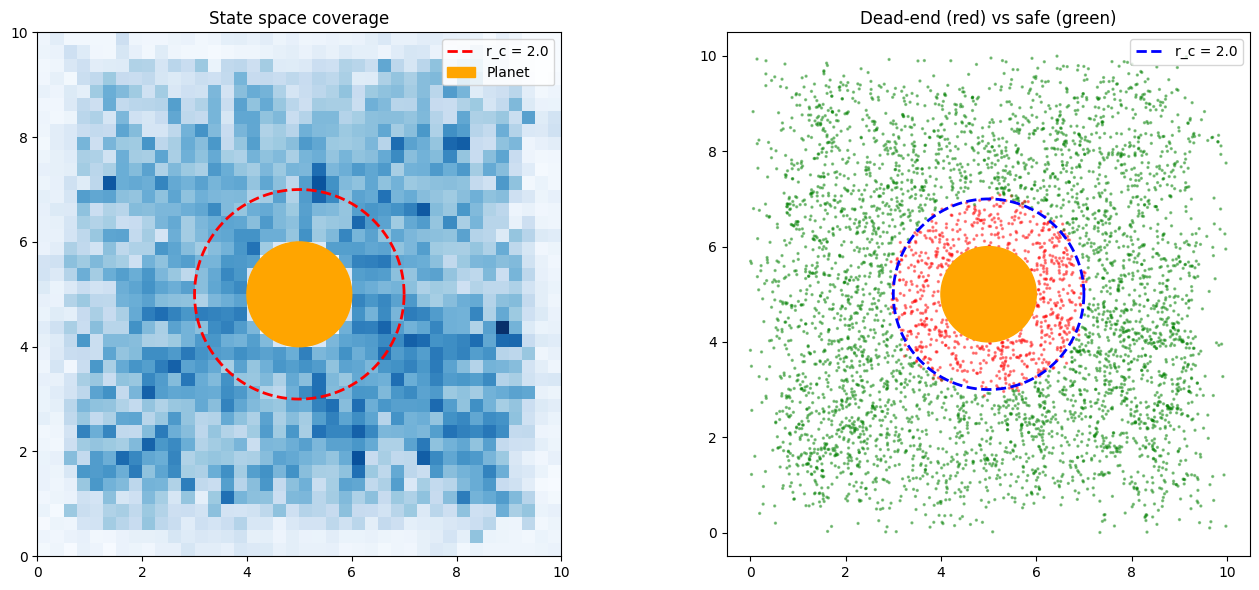

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
theta = np.linspace(0, 2*np.pi, 300)

# Left: coverage heatmap
axes[0].hist2d(df['x'], df['y'], bins=40,
               range=[[0,10],[0,10]], cmap='Blues')
axes[0].plot(5 + 2.0*np.cos(theta), 5 + 2.0*np.sin(theta),
             'r--', linewidth=2, label='r_c = 2.0')
axes[0].add_patch(plt.Circle((5,5), 1.0, color='orange', label='Planet'))
axes[0].set_title('State space coverage')
axes[0].set_aspect('equal')
axes[0].legend()

# Right: dead-end vs safe scatter
sample = df.sample(n=5000, random_state=0)
colors = sample['is_dead_end'].map({True: 'red', False: 'green'})
axes[1].scatter(sample['x'], sample['y'], c=colors, s=2, alpha=0.4)
axes[1].plot(5 + 2.0*np.cos(theta), 5 + 2.0*np.sin(theta),
             'b--', linewidth=2, label='r_c = 2.0')
axes[1].add_patch(plt.Circle((5,5), 1.0, color='orange'))
axes[1].set_title('Dead-end (red) vs safe (green)')
axes[1].set_aspect('equal')
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
df.to_csv('spaceenv_dataset.csv', index=False)
print("Dataset saved.")

Dataset saved.
